In [1]:
from pydantic import BaseModel, Field
from typing_extensions import Literal, TypedDict
from pydantic import Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, StateGraph, START
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import WebBaseLoader
from typing import Annotated, List
import operator
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send
from IPython.display import Markdown, Image

from dotenv import load_dotenv

/var/folders/mp/s7vyjtmd5dj1l_2fflblh8zh0000gn/T/ipykernel_34740/1348738483.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [16]:
def extract_text(response) -> str:
    """ Normalizes an LLM response's content into a plain string.

    Some models (e.g. Gemini) can return `content` as a list of content
    blocks (dicts with a 'text' key, or plain strings) instead of a str.
    """
    if not response:
        return "No summary available."

    content = response.content
    if isinstance(content, list):
        text = "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in content
        )
    else:
        text = content

    return text.strip() if text else "No summary available."

In [2]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )

In [3]:
class SharedState(TypedDict):
    research_topic: str
    model: ChatGoogleGenerativeAI
    sections: list[Section]
    section_contents: Annotated[list[str], operator.add]
    final_report: str

In [4]:
def build_model(shared_state: SharedState) -> SharedState:
    shared_state['model'] = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
    return shared_state

In [5]:
def orchestrator(shared_state: SharedState) -> SharedState:
    model = shared_state['model']
    orchestrator_prompt = ChatPromptTemplate.from_template(
        "Create a detailed outline for a research report on the topic of {research_topic}. "
        "Break the report down into sections, each with a name and brief description. "
        "Limit the report to at max 5 sections."
    )

    model_with_structured_output = model.with_structured_output(Sections)
    retrieval_grader = orchestrator_prompt | model_with_structured_output
    result = retrieval_grader.invoke(
        {
            "research_topic": shared_state['research_topic'],
        }
    )
    shared_state['sections'] = [section for section in result.sections]

    return shared_state

In [6]:
def display_sections(sections: List[Section]) -> None:
    md_content = "## Report Sections\n"
    for idx, section in enumerate(sections, start=1):
        md_content += f"### Section {idx}: {section.name}\n{section.description}\n\n"
    display(Markdown(md_content))

In [7]:
load_dotenv()

shared_state = build_model({'research_topic': 'The impact of AI on modern education.'})
shared_state = orchestrator(shared_state)

display_sections(shared_state['sections'])

## Report Sections
### Section 1: Introduction to AI in the Educational Landscape
This section defines the scope of Artificial Intelligence in education, tracing its evolution from basic computer-aided instruction to modern generative AI and adaptive learning systems.

### Section 2: Enhancing Personalized Learning and Student Engagement
An analysis of how AI-driven platforms customize curriculum content to individual learning speeds, provide 24/7 tutoring support, and use gamification to increase student motivation.

### Section 3: The Evolving Role of Educators and Institutional Efficiency
Explores the transition of teachers from primary lecturers to learning facilitators, alongside the automation of administrative tasks such as grading and attendance tracking.

### Section 4: Ethical Implications, Data Privacy, and the Digital Divide
A critical look at the risks associated with AI in schools, including algorithmic bias, student data security, academic integrity concerns, and the potential for widening the gap between different socioeconomic groups.

### Section 5: Future Outlook and Strategic Recommendations
A summary of long-term trends in AI-integrated classrooms and a set of actionable recommendations for policymakers to ensure equitable and effective implementation of educational technology.



In [8]:
# Worker state
class WorkerState(TypedDict):
    section: Section
    model: ChatGoogleGenerativeAI
    completed_sections: Annotated[list, operator.add]

In [ ]:
def worker(worker_state: WorkerState) -> SharedState:
    """Worker writes a section of the report"""
    print(f"\nWorker Spawned! Working on section: {worker_state['section'].name}")
    model = worker_state['model']
    section = worker_state['section']
    # Generate section
    response = model.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {section.name} and description: {section.description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"section_contents": [extract_text(response)]}

In [11]:
# Conditional edge function to create llm_call workers that each write a section of the report
def spawn_workers(shared_state: SharedState):
    """Assign a worker to each section in the plan"""
    model = shared_state["model"]
    # Kick off section writing in parallel via Send() API
    return [
        Send("worker", {"section": section, "model": model}) 
        for section in shared_state["sections"]
    ]

In [12]:
def synthesizer(shared_state: SharedState):
    """Synthesize full report from sections"""

    # List of completed sections
    section_contents = shared_state["section_contents"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(section_contents)

    return {"final_report": completed_report_sections}

In [13]:
def build_workflow():
    # Build workflow
    orchestrator_worker_builder = StateGraph(SharedState)

    # Add the nodes
    orchestrator_worker_builder.add_node("build_model", build_model)
    orchestrator_worker_builder.add_node("orchestrator", orchestrator)
    orchestrator_worker_builder.add_node("worker", worker)
    orchestrator_worker_builder.add_node("synthesizer", synthesizer)

    # Add edges to connect nodes
    orchestrator_worker_builder.add_edge(START, "build_model")
    orchestrator_worker_builder.add_edge("build_model", "orchestrator")
    orchestrator_worker_builder.add_conditional_edges(
        "orchestrator", spawn_workers, ["worker"]
    )
    orchestrator_worker_builder.add_edge("worker", "synthesizer")
    orchestrator_worker_builder.add_edge("synthesizer", END)

    # Compile the workflow
    return orchestrator_worker_builder.compile()

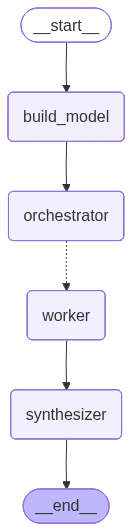

In [14]:
orchestrator_worker = build_workflow()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [15]:
state = orchestrator_worker.invoke({"research_topic": "How to prepare for a System Design technical Interview?"})

Markdown(state["final_report"])


Worker Spawned! Working on section: Understanding Core Distributed Systems Concepts
Worker Spawned! Working on section: Mastering High-Level Architectural Components


Worker Spawned! Working on section: Applying a Structured Interview Framework

Worker Spawned! Working on section: Analyzing Common System Design Patterns and Case Studies

Worker Spawned! Working on section: Refining Communication and Mock Interview Practice


TypeError: sequence item 0: expected str instance, list found